# Netflix Media Consumption Analysis: Exploratory Visual Analysis

This notebook performs descriptive visual analysis of the cleaned Netflix dataset to highlight composition, genre patterns, rating distribution, and keyword prevalence.

## 1. Environment Setup

Import visualization libraries and configure a consistent chart style.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.preprocess import clean_data, feature_engineering, load_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 2. Load and Prepare Data

Load data from the project folder, then apply cleaning and feature engineering.

In [2]:
data_path = Path("../data/raw/netflix_titles.csv")
df = load_data(data_path)
df = clean_data(df)
df = feature_engineering(df)

print(f"Dataset ready: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset ready: 8,807 rows x 17 columns


## 3. Content Type Distribution

Compare the share of Movies vs TV Shows in the catalog.

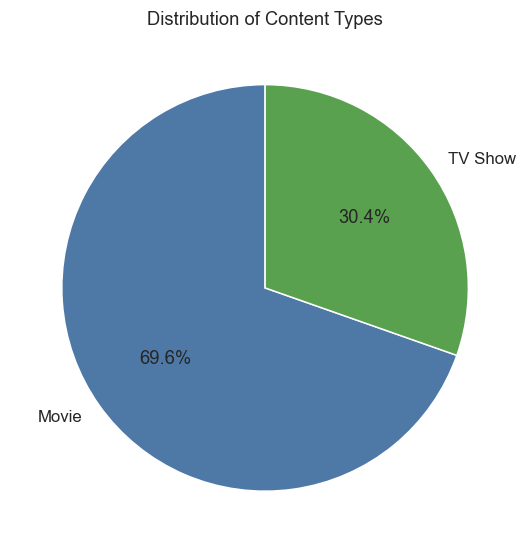

In [3]:
content_type_counts = df["type"].value_counts()

plt.figure(figsize=(6, 6))
content_type_counts.plot.pie(
    autopct="%1.1f%%",
    colors=["#4E79A7", "#59A14F"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Distribution of Content Types")
plt.ylabel("")
plt.show()

## 4. Top Genres

Identify the most common primary genres in the catalog.

C:\Users\a12u\AppData\Local\Temp\ipykernel_13748\1209205337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x="Count", y="Genre", palette="viridis")


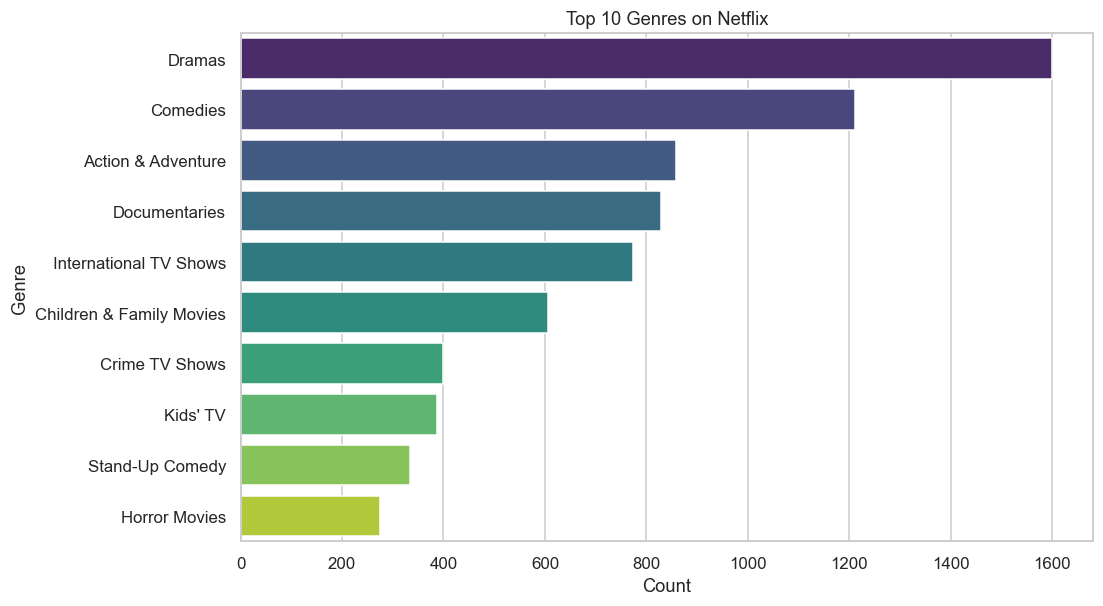

In [4]:
genre_counts = df["primary_genre"].value_counts().head(10).reset_index()
genre_counts.columns = ["Genre", "Count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_counts, x="Count", y="Genre", palette="viridis")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

## 5. Ratings Distribution

Visualize how content is distributed across maturity and audience ratings.

C:\Users\a12u\AppData\Local\Temp\ipykernel_13748\1093907151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_counts, x="Count", y="Rating", palette="coolwarm")


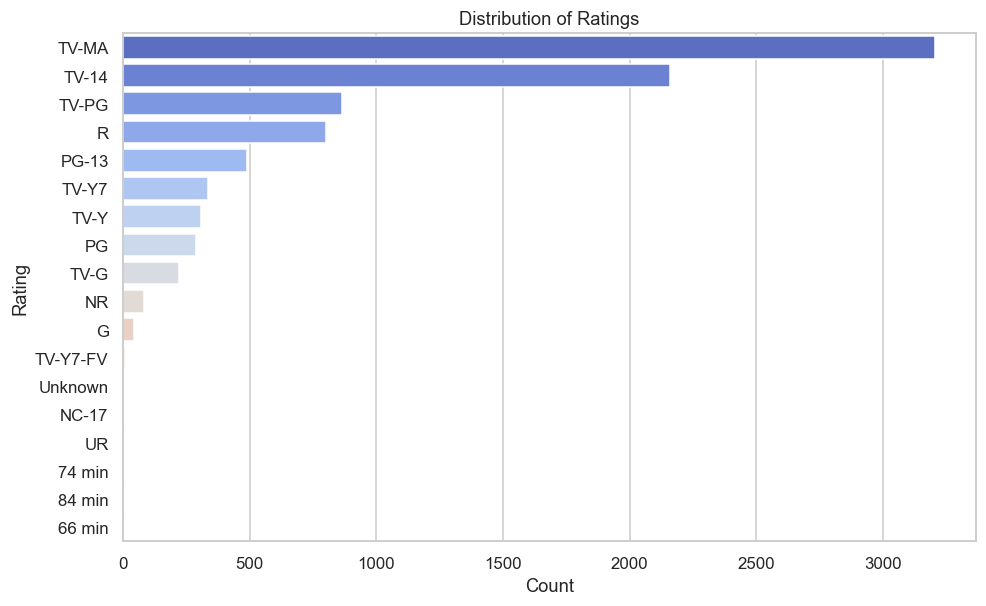

In [5]:
rating_counts = df["rating"].value_counts().reset_index()
rating_counts.columns = ["Rating", "Count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_counts, x="Count", y="Rating", palette="coolwarm")
plt.title("Distribution of Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

## 6. Genre Keyword Word Cloud

Generate a quick textual view of recurring genre keywords in `listed_in`.

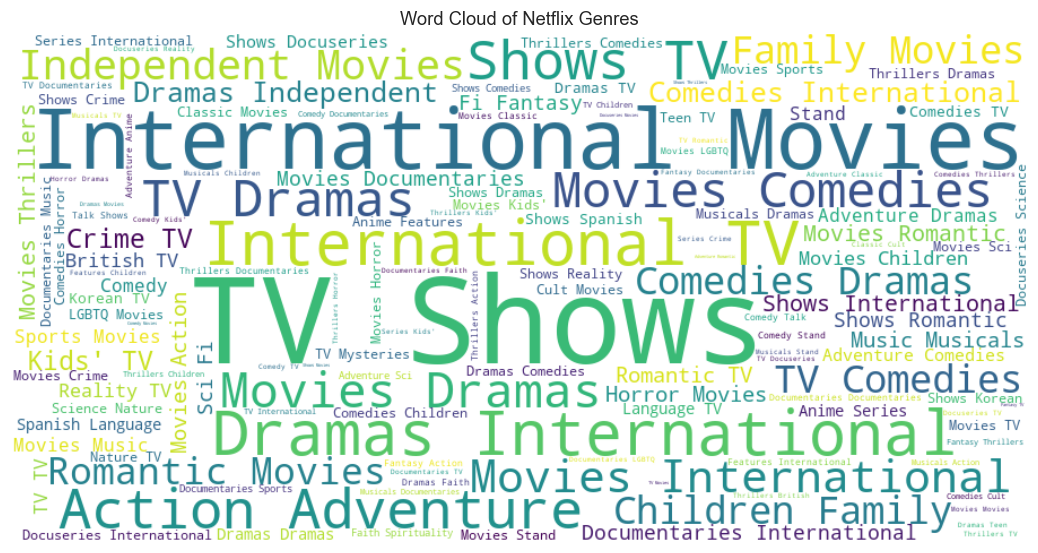

In [6]:
text = " ".join(df["listed_in"].astype(str))
wordcloud = WordCloud(width=900, height=450, background_color="white").generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Netflix Genres")
plt.show()